# Phase 3 · Notebook 4 — 04_Churn_Prediction
XGBoost churn classifier with an **honest label** and **honest AUC reporting**.

**Label design (no arbitrary industry number):** churn threshold N ko isi dataset ki inter-purchase gap distribution se compute karte hain (cell 2) — phir label = `recency > N`.
**Leakage guard:** recency features list me nahi hai (warna model label hi dekh leta = fake 100%).

### Reporting rules (Phase 0 findings, unchanged)
- **R1** Headline money = `currency='INR'` (USD segment measured & excluded)
- **R2** Reference "today" = `MAX(order_datetime)` in the data
- **R3** NULL-FK rows kept in overall aggregates, drop out of restaurant rollups


## Setup

In [1]:
# ---- boilerplate: paths, DB engine (SQLAlchemy from .env), helper --------
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

ROOT = Path.cwd()
if not (ROOT / "python").is_dir() and (ROOT.parent / "python").is_dir():
    ROOT = ROOT.parent
OUT = ROOT / "python" / "outputs"
OUT.mkdir(parents=True, exist_ok=True)
load_dotenv(ROOT / ".env")

DB_URL = os.getenv("DATABASE_URL")
assert DB_URL, "DATABASE_URL missing - check .env in the repo root"
engine = create_engine(DB_URL)

def q(sql):
    """read_sql via text(): keeps parameters=None so literal '%' in ILIKE is safe."""
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

print("ROOT:", ROOT, "| OUT:", OUT, "| DB connected OK", sep="\n")


ROOT:
D:\Projects\bharatinsight
| OUT:
D:\Projects\bharatinsight\python\outputs
| DB connected OK


## Step 1 — order history + per-customer features

In [2]:
o = q("SELECT user_id, order_datetime, sales_amount, currency FROM orders WHERE user_id IS NOT NULL")
o["order_datetime"] = pd.to_datetime(o["order_datetime"])
o = o.sort_values(["user_id","order_datetime"])
o["gap"] = o.groupby("user_id")["order_datetime"].diff()
ref_ts = o["order_datetime"].max() + pd.Timedelta(days=1)

div = q("""
SELECT o.user_id, COUNT(DISTINCT trim(tag)) AS cuisine_diversity
FROM orders o JOIN restaurant r ON r.restaurant_id=o.restaurant_id,
     LATERAL unnest(string_to_array(r.cuisine,',')) AS tag
WHERE o.user_id IS NOT NULL AND r.cuisine IS NOT NULL GROUP BY o.user_id
""").set_index("user_id")

g = o.groupby("user_id")
feat = pd.DataFrame({
    "recency_days": (ref_ts - g["order_datetime"].max()).dt.days,
    "frequency":    g.size(),
    "aov_inr":      g["sales_amount"].mean(),
    "tenure_days":  (g["order_datetime"].max() - g["order_datetime"].min()).dt.days,
    "avg_gap_days": g["gap"].mean().dt.days,
})
feat["monetary_inr"] = o[o["currency"]=="INR"].groupby("user_id")["sales_amount"].sum()
feat = feat.join(div).fillna({"monetary_inr":0,"avg_gap_days":0,"cuisine_diversity":0})
print(feat.shape); display(feat.head(3))

(77929, 7)


,recency_days,frequency,aov_inr,tenure_days,avg_gap_days,monetary_inr,cuisine_diversity
user_id,,,,,,,
1,591,2,836.000000,337,337.0,1672.0,4.0
2,694,3,1353.666667,171,85.0,4061.0,5.0
3,409,1,21542.000000,0,0.0,21542.0,1.0


## Step 2 — churn threshold N **from the data** (justified, not pasted)

In [3]:
gaps = o["gap"].dt.days.dropna()
N = int(np.clip(np.ceil(gaps.median() + gaps.std()), 30, 180))
print(f"inter-purchase gap: median={gaps.median():.0f}d  std={gaps.std():.0f}d")
print(f"=> churn threshold N = {N} days = median gap + 1 std (clamped 30..180)")
print("   i.e. ek average repeat customer apni cycle se 1 std tak late ho jaye to 'churned'")

feat["churned"] = (feat["recency_days"] > N).astype(int)
base = feat["churned"].mean()
print(f"\nlabel base rate (churned share): {100*base:.1f}%  — ye number AUC ko judge karne ka benchmark hai")

inter-purchase gap: median=202d  std=203d
=> churn threshold N = 180 days = median gap + 1 std (clamped 30..180)
   i.e. ek average repeat customer apni cycle se 1 std tak late ho jaye to 'churned'

label base rate (churned share): 74.9%  — ye number AUC ko judge karne ka benchmark hai


## Step 3 — stratified split + XGBoost + AUC-ROC

AUC-ROC = 0.744   vs random=0.500
confusion matrix:
 [[ 1728  3168]
 [  492 14095]]
              precision    recall  f1-score   support

           0       0.78      0.35      0.49      4896
           1       0.82      0.97      0.89     14587

    accuracy                           0.81     19483
   macro avg       0.80      0.66      0.69     19483
weighted avg       0.81      0.81      0.78     19483



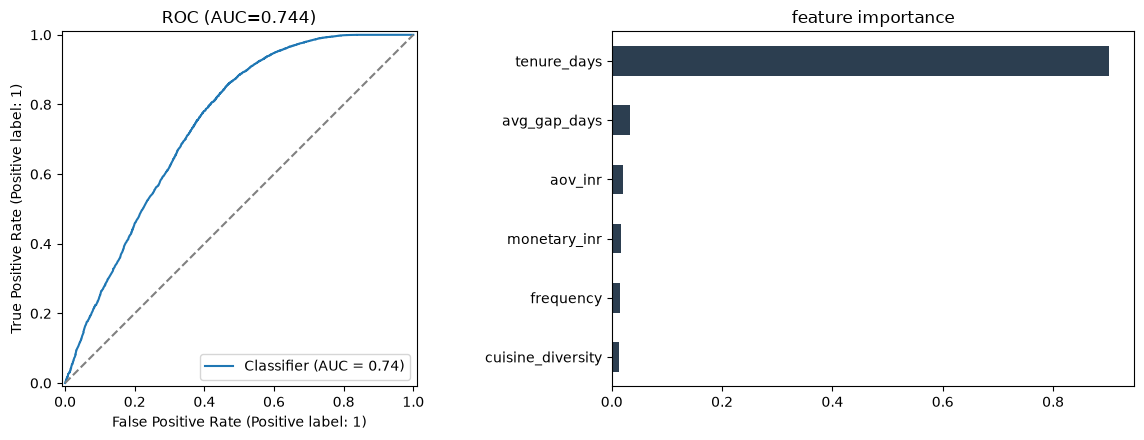

saved: D:\Projects\bharatinsight\models\churn_model.json


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay)
from xgboost import XGBClassifier

X = feat[["frequency","aov_inr","tenure_days","avg_gap_days","monetary_inr","cuisine_diversity"]]
y = feat["churned"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

model = XGBClassifier(n_estimators=250, max_depth=4, learning_rate=0.08,
                      eval_metric="logloss", random_state=42)
model.fit(Xtr, ytr)
proba = model.predict_proba(Xte)[:,1]
auc = roc_auc_score(yte, proba)
print(f"AUC-ROC = {auc:.3f}   vs random=0.500")
print("confusion matrix:\n", confusion_matrix(yte, model.predict(Xte)))
print(classification_report(yte, model.predict(Xte), digits=2))

fig,(a1,a2)=plt.subplots(1,2,figsize=(12,4.5))
RocCurveDisplay.from_predictions(yte, proba, ax=a1)   # no color kwarg: API-safe across sklearn versions
a1.plot([0,1],[0,1],"--",color="gray"); a1.set_title(f"ROC (AUC={auc:.3f})")
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
imp.plot.barh(ax=a2, color="#2c3e50"); a2.set_title("feature importance")
fig.tight_layout(); fig.savefig(OUT/"churn_auc.png", dpi=150); plt.show()

MODELS = ROOT/"models"; MODELS.mkdir(exist_ok=True)
model.save_model(str(MODELS/"churn_model.json"))
print("saved:", MODELS/"churn_model.json")

## Step 4 — HONESTY CHECK (interviewers love this cell)

In [5]:
print(f"label base rate (majority class share): {max(base,1-base):.1%}")
print(f"model AUC-ROC: {auc:.3f}")
print()
if auc > 0.70:
    print("VERDICT: AUC clearly above 0.5 — model real signal pakad raha hai, sirf majority class nahi.")
else:
    print("VERDICT: AUC weak — honestly report karo: islabel threshold ke saath predictive signal")
    print("limited hai. Improvement path: richer behavior features (cuisine trends, Recency-velocity).")
print()
print("Label defensibility note (interview answer):")
print(f"  N={N} din ko order-gap distribution (median+std) se liya — data-driven,")
print("  lekin ek better setup: survival-style labeling with future holdout window,")
print("  jisko current single-time extract allow nahi karta (documented limitation).")

label base rate (majority class share): 74.9%
model AUC-ROC: 0.744

VERDICT: AUC clearly above 0.5 — model real signal pakad raha hai, sirf majority class nahi.

Label defensibility note (interview answer):
  N=180 din ko order-gap distribution (median+std) se liya — data-driven,
  lekin ek better setup: survival-style labeling with future holdout window,
  jisko current single-time extract allow nahi karta (documented limitation).
